# Data Visualisation

This notebook continues [01_data_exploration.ipynb](01_data_exploration.ipynb). It loads the saved processed CSV directly and does not need the exploration notebook to be run in the same session.

Use the existing cleaned dataset, `data/processed/ld50_cleaned.csv`, for these
exploratory plots. The `LD50` column already contains **−log10(LD50 mol/kg)**:
**higher values indicate greater acute toxicity**. Do not apply another log transformation.

All 7,388 cleaned records are retained. The main boxplot uses a minimum group
size for readability, and the two molecular-weight checks use records with
available molecular weight; these plotting choices are explained below and
do not change either CSV. Figures are saved in `figures/`.
No final hypothesis test or assessment of statistical significance is performed here.

## Plotting setup

Run the setup cell below once to import the libraries, load the processed CSV and
set the figure folder and style. Then run any of the six labelled graph cells.
Each graph cell contains its own calculations, plotting commands, save command
and `plt.show()`; none of the graph code is hidden in a helper function or script.


In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Locate the processed data from the project root or notebooks/ directory.
project_root = Path.cwd()
if not (project_root / 'data/processed/ld50_cleaned.csv').is_file():
    project_root = project_root.parent
visual_df = pd.read_csv(project_root / 'data/processed/ld50_cleaned.csv')
figures_dir = project_root / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# Check the plotting variables without changing or removing records.
assert np.isfinite(visual_df[['LD50', 'NumHAcceptors']]).all().all()
assert visual_df['NumHAcceptors'].ge(0).all()
assert visual_df['NumHAcceptors'].mod(1).eq(0).all()

# Use the same readable style for all six graphs.
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
# Reuse the axis label and colours in each graph cell.
toxicity_label = r'$-\log_{10}(\mathrm{LD}_{50}\;\mathrm{mol/kg})$'
blue = '#2878A5'
orange = '#C46A18'

print(f'Loaded {len(visual_df):,} cleaned compounds for visualisation.')

Loaded 7,388 cleaned compounds for visualisation.


## 1. Distribution of Acute Toxicity

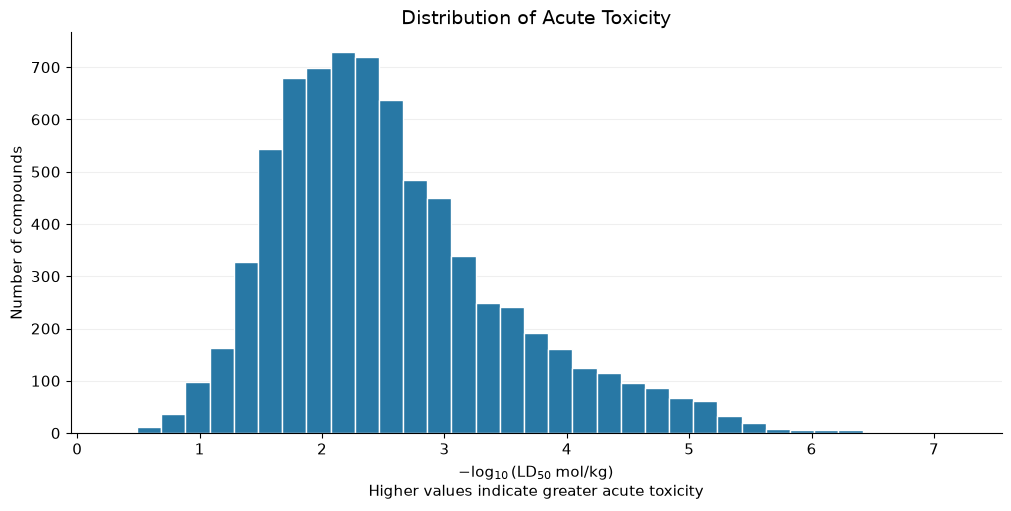

In [21]:
# Graph 1: distribution of LD50.
fig, ax = plt.subplots(figsize=(10, 5), layout='constrained')
# LD50 is already on the negative log10 scale; count compounds in 35 bins.
ax.hist(visual_df['LD50'], bins=35, color=blue, edgecolor='white')
# Add the title, axis labels and a light grid.
ax.set_title('Distribution of Acute Toxicity')
ax.set_xlabel(toxicity_label + '\nHigher values indicate greater acute toxicity')
ax.set_ylabel('Number of compounds')
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
# Save this graph to figures/ with the original resolution and filename.
fig.savefig(figures_dir / 'ld50_distribution.png', dpi=180, bbox_inches='tight')

# Display the graph in the notebook, then close the figure.
plt.show()
plt.close(fig)

This histogram shows the distribution of the stored toxicity values across
all cleaned compounds. Moving right means greater acute toxicity on the
−log10(LD50 mol/kg) scale.

## 2. Distribution of Hydrogen-Bond Acceptors

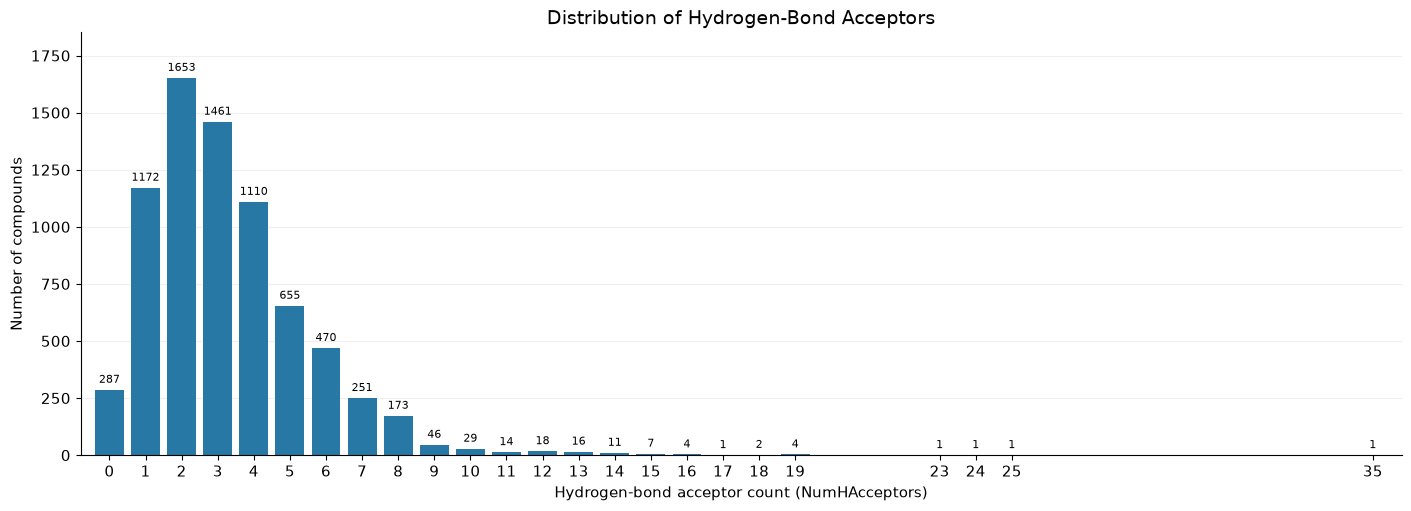

In [22]:
# Graph 2: distribution of hydrogen-bond acceptor counts.
# Count each discrete acceptor value; no continuous histogram bins are used.
group_counts = visual_df['NumHAcceptors'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5), layout='constrained')
# Draw one bar for each observed integer count.
bars = ax.bar(group_counts.index, group_counts.values, color=blue, width=0.8)
# Write the number of compounds above each bar.
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('Distribution of Hydrogen-Bond Acceptors')
ax.set_xlabel('Hydrogen-bond acceptor count (NumHAcceptors)')
ax.set_ylabel('Number of compounds')
ax.set_xticks(group_counts.index)
ax.set_xlim(-0.8, group_counts.index.max() + 0.8)
ax.margins(y=0.12)
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
# Save this graph to figures/ with the original resolution and filename.
fig.savefig(figures_dir / 'hbond_acceptor_distribution.png', dpi=180, bbox_inches='tight')

# Display the graph in the notebook, then close the figure.
plt.show()
plt.close(fig)

Each bar counts the compounds with an observed integer `NumHAcceptors` value.
Bar labels show group sizes, including the rare high-count groups. The bar
chart treats hydrogen-bond acceptors as a discrete count.

## 3. Acute Toxicity by Hydrogen-Bond Acceptor Count

**Main graph for the research question.** For readability, show groups with
**at least 20 compounds**. This descriptive threshold avoids giving very small
groups, whose quartiles are based on few observations, equal space in the main
comparison; it is not a statistical significance threshold.

In the current dataset, counts **0–10** meet this rule: **7,307 compounds** are
shown. The **81 compounds in 13 groups** with fewer than 20 records (observed
counts 11–19, 23–25 and 35) are omitted **only from this boxplot**. They remain
in the dataset, the acceptor distribution and the full median summary below.

Boxplot: 7,307 compounds shown; 81 omitted from this plot only.


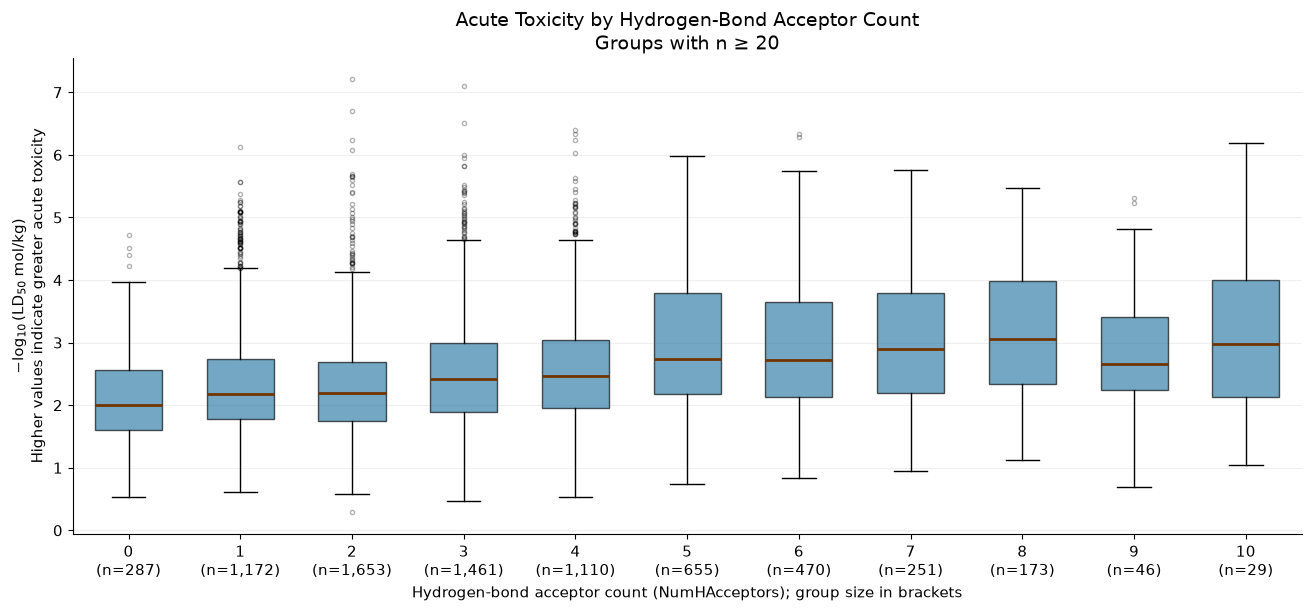

In [23]:
# Graph 3: compare toxicity distributions across acceptor-count groups.
# Count the compounds in each group within this cell.
group_counts = visual_df['NumHAcceptors'].value_counts().sort_index()

# Use groups with at least 20 compounds for this plot only.
min_group_size = 20
boxplot_groups = group_counts[group_counts >= min_group_size].index
boxplot_df = visual_df.loc[visual_df['NumHAcceptors'].isin(boxplot_groups)]
# Collect each group's toxicity values and its label for the boxplot.
toxicity_groups = []
boxplot_labels = []
for count in boxplot_groups:
    group_ld50 = boxplot_df.loc[boxplot_df['NumHAcceptors'] == count, 'LD50']
    toxicity_groups.append(group_ld50.to_numpy())
    boxplot_labels.append(f'{count}\n(n={group_counts.loc[count]:,})')

fig, ax = plt.subplots(figsize=(13, 6), layout='constrained')
# Show each group as a boxplot, including points beyond the whiskers.
ax.boxplot(
    toxicity_groups,
    tick_labels=boxplot_labels,
    patch_artist=True,
    widths=0.6,
    showfliers=True,
    boxprops={'facecolor': blue, 'alpha': 0.65},
    medianprops={'color': '#713400', 'linewidth': 2},
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
)
ax.set_title(f'Acute Toxicity by Hydrogen-Bond Acceptor Count\nGroups with n ≥ {min_group_size}')
ax.set_xlabel('Hydrogen-bond acceptor count (NumHAcceptors); group size in brackets')
ax.set_ylabel(toxicity_label + '\nHigher values indicate greater acute toxicity')
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
print(f'Boxplot: {len(boxplot_df):,} compounds shown; '
      f'{len(visual_df) - len(boxplot_df):,} omitted from this plot only.')
# Save this graph to figures/ with the original resolution and filename.
fig.savefig(figures_dir / 'toxicity_by_hbond_acceptors.png', dpi=180, bbox_inches='tight')

# Display the graph in the notebook, then close the figure.
plt.show()
plt.close(fig)

These boxplots compare toxicity distributions across acceptor counts for the
main research question. The centre line is the median, the box spans the middle
50% of values, and whiskers extend to the most extreme observations within
1.5 interquartile ranges of the box. Points beyond the whiskers are displayed
and retained. Group sizes appear below the boxes.

## 4. Median Toxicity by Hydrogen-Bond Acceptor Count

Include **every observed acceptor count**. The table reports the median and
number of compounds in each group; triangle markers identify groups with
fewer than 20 compounds so their sparse support remains visible.

,n_compounds,median_LD50,sparse_group
NumHAcceptors,,,
0,287,1.9960,False
1,1172,2.1770,False
2,1653,2.1870,False
3,1461,2.4150,False
4,1110,2.4730,False
5,655,2.7360,False
6,470,2.7180,False
7,251,2.9050,False
8,173,3.0570,False


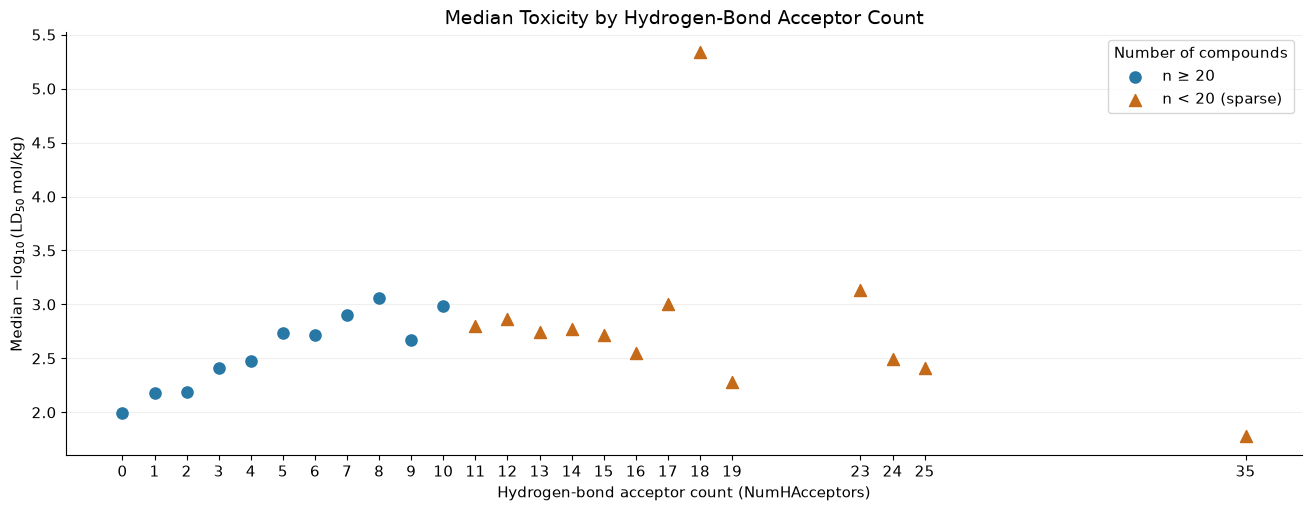

In [24]:
# Graph 4: median toxicity for every observed acceptor count.
# Keep the same threshold for marking sparse groups; do not remove them.
min_group_size = 20

# Calculate the number of compounds and median LD50 in each group.
acceptor_summary = (
    visual_df.groupby('NumHAcceptors', sort=True)['LD50']
    .agg(n_compounds='size', median_LD50='median')
)
# Flag groups with fewer than 20 compounds and display the full table.
acceptor_summary['sparse_group'] = acceptor_summary['n_compounds'] < min_group_size
display(acceptor_summary)

# Split the table only to give sparse groups a different marker.
common_groups = acceptor_summary.loc[~acceptor_summary['sparse_group']]
sparse_groups = acceptor_summary.loc[acceptor_summary['sparse_group']]
fig, ax = plt.subplots(figsize=(13, 5), layout='constrained')
# Plot common groups as circles and sparse groups as triangles.
ax.scatter(common_groups.index, common_groups['median_LD50'],
           color=blue, s=65, label=f'n ≥ {min_group_size}')
ax.scatter(sparse_groups.index, sparse_groups['median_LD50'],
           color=orange, marker='^', s=75, label=f'n < {min_group_size} (sparse)')
ax.set_title('Median Toxicity by Hydrogen-Bond Acceptor Count')
ax.set_xlabel('Hydrogen-bond acceptor count (NumHAcceptors)')
ax.set_ylabel('Median ' + toxicity_label)
ax.set_xticks(acceptor_summary.index)
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
ax.legend(title='Number of compounds')
# Save this graph to figures/ with the original resolution and filename.
fig.savefig(figures_dir / 'median_toxicity_by_hbond_acceptors.png', dpi=180, bbox_inches='tight')

# Display the graph in the notebook, then close the figure.
plt.show()
plt.close(fig)

This plot compares the median stored toxicity value for every acceptor-count
group, including those omitted from the boxplot. The accompanying counts and
sparse-group markers show how many compounds support each median; the markers
are descriptive summaries, not estimates of statistical significance.

## 5. Molecular Weight vs Hydrogen-Bond Acceptor Count

Molecular weight is missing for **5 of the 7,388 compounds**. Use the **7,383
records with finite `MolWt`** for this plot and the supporting regression below.
Those five records remain in the cleaned dataset and in all toxicity-only plots.
Keep every acceptor-count group with available molecular weight, including sparse groups.

Molecular-weight checks: 7,383 compounds included; 5 without finite MolWt omitted only here.


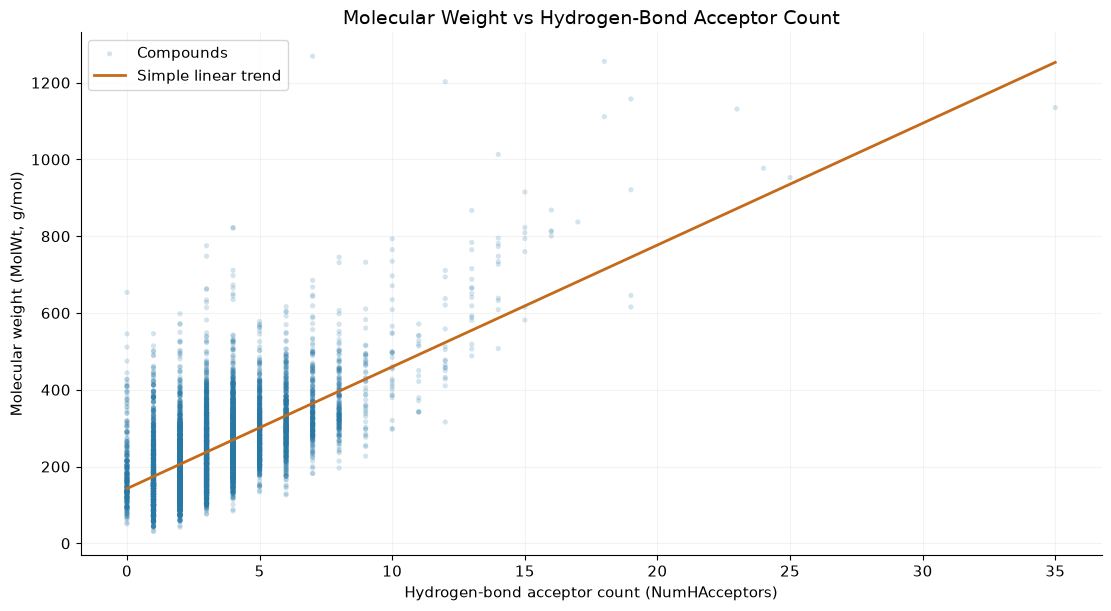

In [25]:
# Graph 5: molecular weight versus hydrogen-bond acceptor count.
# Use a separate plotting subset; visual_df and the cleaned CSV stay unchanged.
molwt_df = visual_df.loc[np.isfinite(visual_df['MolWt'])].copy()
print(f'Molecular-weight checks: {len(molwt_df):,} compounds included; '
      f'{len(visual_df) - len(molwt_df):,} without finite MolWt omitted only here.')

# Fit a descriptive straight line: MolWt = intercept + slope * NumHAcceptors.
# The final argument, 1, selects a straight-line fit.
size_slope, size_intercept = np.polyfit(molwt_df['NumHAcceptors'], molwt_df['MolWt'], 1)
# Create evenly spaced acceptor counts to draw the fitted line.
acceptor_grid = np.linspace(molwt_df['NumHAcceptors'].min(),
                            molwt_df['NumHAcceptors'].max(), 200)

fig, ax = plt.subplots(figsize=(11, 6), layout='constrained')
# Plot every available compound, using transparency where points overlap.
ax.scatter(molwt_df['NumHAcceptors'], molwt_df['MolWt'],
           color=blue, s=14, alpha=0.2, edgecolors='none', label='Compounds')
# Draw the fitted trend line over the scatter plot.
ax.plot(acceptor_grid, size_intercept + size_slope * acceptor_grid,
        color=orange, linewidth=2, label='Simple linear trend')
ax.set_title('Molecular Weight vs Hydrogen-Bond Acceptor Count')
ax.set_xlabel('Hydrogen-bond acceptor count (NumHAcceptors)')
ax.set_ylabel('Molecular weight (MolWt, g/mol)')
ax.set_xticks(np.arange(0, int(molwt_df['NumHAcceptors'].max()) + 1, 5))
ax.grid(alpha=0.15)
ax.set_axisbelow(True)
ax.legend()
# Save this graph to figures/ with the original resolution and filename.
fig.savefig(figures_dir / 'molecular_weight_vs_hbond_acceptors.png', dpi=180, bbox_inches='tight')

# Display the graph in the notebook, then close the figure.
plt.show()
plt.close(fig)

This scatter plot checks whether compounds with more hydrogen-bond acceptors
also tend to have greater molecular weight. Each point is one compound, and
the fitted straight line provides a descriptive guide to the overall pattern.

## 6. Hydrogen-Bond Acceptors vs Toxicity After Accounting for Molecular Weight

**Exploratory supporting analysis only.** Fit a simple linear regression with
an intercept: `LD50 = intercept + slope × MolWt`. Subtract the predicted stored
toxicity value from the observed value to obtain each LD50 residual, using the
same 7,383 complete records as above. No acceptor-count group-size filter is applied.

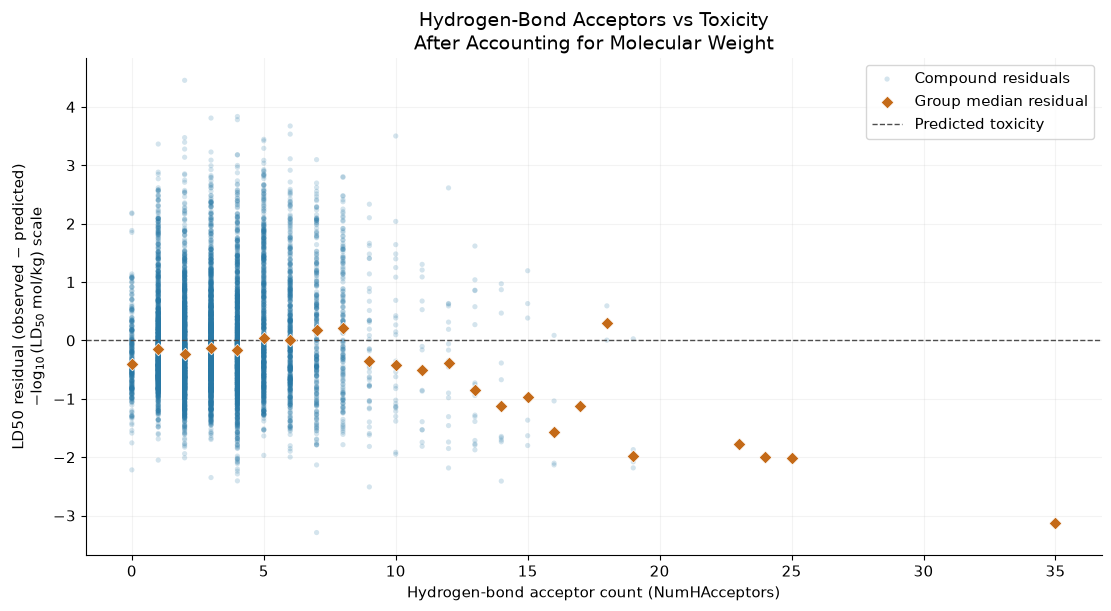

In [26]:
# Graph 6: toxicity residuals after accounting for molecular weight.
# Create this subset here so the cell does not depend on running Graph 5.
# Omit missing molecular weights only from this plot; keep the dataset unchanged.
molwt_df = visual_df.loc[np.isfinite(visual_df['MolWt'])].copy()

# Fit a straight line: LD50 = intercept + slope * MolWt.
toxicity_slope, toxicity_intercept = np.polyfit(molwt_df['MolWt'], molwt_df['LD50'], 1)
# Use molecular weight to predict each compound's stored LD50 value.
molwt_df['predicted_LD50'] = toxicity_intercept + toxicity_slope * molwt_df['MolWt']
# Residual = observed toxicity minus predicted toxicity.
molwt_df['LD50_residual'] = molwt_df['LD50'] - molwt_df['predicted_LD50']
# Calculate a median residual for every acceptor-count group.
residual_medians = molwt_df.groupby('NumHAcceptors')['LD50_residual'].median()

fig, ax = plt.subplots(figsize=(11, 6), layout='constrained')
# Show the individual residuals and overlay the group medians as diamonds.
ax.scatter(molwt_df['NumHAcceptors'], molwt_df['LD50_residual'],
           color=blue, s=14, alpha=0.2, edgecolors='none', label='Compound residuals')
ax.scatter(residual_medians.index, residual_medians.values,
           color=orange, marker='D', s=42, edgecolors='white', linewidths=0.5,
           label='Group median residual', zorder=3)
# Zero means observed toxicity equals the model prediction.
ax.axhline(0, color='0.3', linestyle='--', linewidth=1, label='Predicted toxicity')
ax.set_title('Hydrogen-Bond Acceptors vs Toxicity\nAfter Accounting for Molecular Weight')
ax.set_xlabel('Hydrogen-bond acceptor count (NumHAcceptors)')
ax.set_ylabel('LD50 residual (observed − predicted)\n' + toxicity_label + ' scale')
ax.set_xticks(np.arange(0, int(molwt_df['NumHAcceptors'].max()) + 1, 5))
ax.grid(alpha=0.15)
ax.set_axisbelow(True)
ax.legend()
# Save this graph to figures/ with the original resolution and filename.
fig.savefig(figures_dir / 'hbond_toxicity_controlling_molwt.png', dpi=180, bbox_inches='tight')

# Display the graph in the notebook, then close the figure.
plt.show()
plt.close(fig)

This plot checks whether a pattern with acceptor count remains after subtracting
the simple linear effect of molecular weight from toxicity. Positive residuals
mean greater acute toxicity than the molecular-weight model predicts; negative
residuals mean less. Diamonds mark group medians, including sparse groups.

This is a descriptive check that removes only the fitted linear molecular-weight
component from `LD50`. It does not account for other molecular properties or
establish an independent or causal effect of acceptor count, statistical significance,
or final proof of the hypothesis.